# 12 · 다변량 Gaussian에서 entropy·KL·추정으로

**완성할 것:** 평균과 공분산으로 점을 생성하고, 로그 밀도를 계산합니다. 관측에서 Gaussian의 파라미터를 학습하고, 두 분포를 비교하는 KL을 직접 구현·미분합니다.

[02 확률과 손실](../00_기초/02_probability_and_losses.ipynb)의 우도·기댓값, [11 선형대수](11_linear_algebra.ipynb)의 공분산·행렬곱을 이어갑니다.
이 계산은 VAE의 잠재분포와 diffusion의 잡음 분포로 연결됩니다. [전체 경로](../../docs/CURRICULUM.md), [그림 보조 코드](../../src/utils/bridge_plots.py).

| 기호 | shape | 의미 |
|---|---|---|
| $X$ | $(N,D)$ | 관측 또는 샘플 |
| $\mu,\ell$ | $(D,)$ 또는 $(N,D)$ | 평균, 좌표별 분산의 자연로그 |
| $\Sigma$ | $(D,D)$ | 공분산 |
| $L$ | $(D,D)$ | $\Sigma=LL^T$인 아래삼각행렬 |

로그의 밑은 $e$이며 정보량의 단위는 nat입니다. $\ell=\log\sigma^2$이면 분산은 $e^\ell$, 표준편차는 $e^{\ell/2}$입니다.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.bridge_plots import plot_clouds, plot_curves, plot_matrices, plot_bars
setup_plots()
np.set_printoptions(precision=5, suppress=True)

## 1. 독립 잡음을 상관 있는 점으로 바꾸기

열벡터로 $\epsilon\sim\mathcal N(0,I)$, $x=\mu+L\epsilon$이면
$\mathbb E[x]=\mu$, $\operatorname{Cov}(x)=L\mathbb E[\epsilon\epsilon^T]L^T=LL^T$입니다.
관측을 **행에 저장**하면 같은 식이 `epsilon @ L.T + mu`입니다.

공분산이 대칭 양의 정부호이면 `np.linalg.cholesky`가 $\Sigma=LL^T$인 $L$을 반환합니다.
양의 정부호는 모든 0이 아닌 $v$에서 $v^T\Sigma v>0$인 조건입니다. 이 절에서는 공간 전체에 밀도를 가지는 Gaussian을 사용합니다.

손계산: $L=\left[\begin{smallmatrix}2&0\\1&1\end{smallmatrix}\right]$이면 $\Sigma=\left[\begin{smallmatrix}4&2\\2&2\end{smallmatrix}\right]$입니다.

In [2]:
def sample_gaussian(mu, covariance, count, rng):
    L = np.linalg.cholesky(covariance)
    epsilon = rng.normal(size=(count, len(mu)))
    return epsilon @ L.T + mu

In [3]:
L_hand = np.array([[2., 0.], [1., 1.]])
Sigma = L_hand @ L_hand.T
mu = np.array([1., -2.])
np.testing.assert_allclose(Sigma, [[4., 2.], [2., 2.]])
np.testing.assert_allclose(np.linalg.cholesky(Sigma), L_hand)
rng = np.random.default_rng(120)
samples = sample_gaussian(mu, Sigma, 30000, rng)
centered = samples - samples.mean(axis=0)
empirical_covariance = centered.T @ centered / len(samples)
np.testing.assert_allclose(samples.mean(axis=0), mu, atol=.04)
np.testing.assert_allclose(empirical_covariance, Sigma, atol=.09)
print('생성 평균:', samples.mean(axis=0), '\n생성 공분산:\n', empirical_covariance)

생성 평균: [ 1.00867 -1.99173] 
생성 공분산:
 [[4.02464 1.98654]
 [1.98654 1.9867 ]]


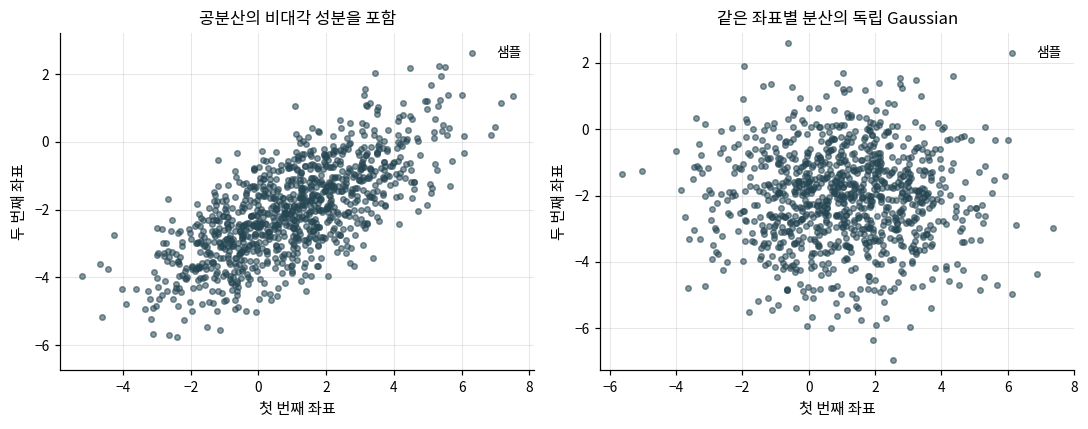

In [4]:
independent_samples = sample_gaussian(mu, np.diag(np.diag(Sigma)), 1000, rng)
plot_clouds([('공분산의 비대각 성분을 포함', {'샘플': samples[:1000]}),
             ('같은 좌표별 분산의 독립 Gaussian', {'샘플': independent_samples})])

두 분포의 좌표별 분산은 같습니다. 첫 분포는 두 좌표가 함께 움직이는 관계를 공분산에 담습니다.
Gaussian에서는 대각 공분산이 좌표들의 독립성을 뜻합니다. 일반 분포의 공분산 0은 선형 상관이 0이라는 정보입니다.

## 2. 로그 밀도: 거리와 부피

$$\log p(x)=-\frac12\left[D\log(2\pi)+\log\det\Sigma+(x-\mu)^T\Sigma^{-1}(x-\mu)\right].$$

세 항은 차원에 따른 상수, 분포가 퍼진 부피, 분포의 축별 크기를 고려한 제곱 거리입니다.
$\Sigma=LL^T$에서 $u=L^{-1}(x-\mu)$를 구하면 마지막 항은 $\|u\|^2$입니다.
행렬식은 부피의 배율이고, 삼각행렬에서는 대각 성분들의 곱입니다. 따라서 $\log\det\Sigma=2\sum_j\log L_{jj}$입니다.
`solve(L, residual.T)`는 관측 각각에 대한 선형 방정식을 동시에 풉니다.

In [5]:
def gaussian_logpdf(X, mu, covariance):
    L = np.linalg.cholesky(covariance)
    standardized = np.linalg.solve(L, (X - mu).T).T
    distance = np.sum(standardized**2, axis=1)
    log_determinant = 2 * np.log(np.diag(L)).sum()
    return -.5 * (X.shape[1] * np.log(2 * np.pi) + log_determinant + distance)

In [6]:
at_mean = gaussian_logpdf(mu[None, :], mu, Sigma)
np.testing.assert_allclose(at_mean, [-np.log(2*np.pi) - np.log(2)])
points = samples[:5]
reference_distance = np.sum((points - mu) * np.linalg.solve(Sigma, (points - mu).T).T, axis=1)
_, reference_logdet = np.linalg.slogdet(Sigma)  # 행렬식의 부호와 로그 절댓값
reference_logpdf = -.5 * (2 * np.log(2*np.pi) + reference_logdet + reference_distance)
np.testing.assert_allclose(gaussian_logpdf(points, mu, Sigma), reference_logpdf)
print('평균 위치의 로그 밀도:', at_mean[0])

평균 위치의 로그 밀도: -2.5310242469692907


## 3. entropy·cross-entropy·KL을 같은 합으로 보기

이산 분포 $p_i$에서 관측 $i$의 정보량을 $-\log p_i$로 정하면, 평균 정보량은
$H(p)=-\sum_i p_i\log p_i$입니다. 이를 **entropy**라고 합니다.
관측은 $p$를 따르고 예측에는 $q$를 쓰면 **cross-entropy** $H(p,q)=-\sum_i p_i\log q_i$입니다.
그 차이가 **KL divergence** 입니다.

$$D_{KL}(p\|q)=\sum_i p_i\log\frac{p_i}{q_i}=H(p,q)-H(p).$$

$\log u\le u-1$에 $u=q_i/p_i$를 대입하고 $p_i$로 가중합하면 $-D_{KL}(p\|q)\le\sum_{i:p_i>0}q_i-1\le0$이므로 KL은 0 이상입니다.
$D_{KL}(p\|q)$의 평균은 **첫 번째 분포 $p$**를 따릅니다. 순서를 바꾸면 값이 달라집니다.
$p_i=0$인 항은 기여 0, $p_i>0,q_i=0$인 항은 무한대입니다.

분류 라벨 하나를 확률 1인 분포로 보면 entropy는 0이며 CE는 $-\log q_y$가 됩니다. 여러 관측의 평균이 02의 분류 손실입니다.

In [7]:
def check_distribution(p):
    p = np.asarray(p, dtype=float)
    if p.ndim != 1 or np.any(~np.isfinite(p)) or np.any(p < 0) or not np.isclose(p.sum(), 1):
        raise ValueError('합이 1인 유한한 비음수 확률 벡터를 사용합니다.')
    return p


def cross_entropy(p, q):
    p, q = check_distribution(p), check_distribution(q)
    if p.shape != q.shape:
        raise ValueError('p와 q는 같은 사건들을 나타냅니다.')
    active = p > 0
    if np.any(q[active] == 0):
        return np.inf
    return -np.sum(p[active] * np.log(q[active]))


def entropy(p):
    return cross_entropy(p, p)


def categorical_kl(p, q):
    return cross_entropy(p, q) - entropy(p)

In [8]:
p = np.array([.75, .25])
q = np.array([.5, .5])
hand_kl = .75 * np.log(1.5) + .25 * np.log(.5)
np.testing.assert_allclose(categorical_kl(p, q), hand_kl)
assert not np.isclose(categorical_kl(p, q), categorical_kl(q, p))
assert entropy([1., 0.]) == 0
assert np.isinf(categorical_kl([1., 0.], [0., 1.]))
np.testing.assert_allclose(entropy([.5, .5]), np.log(2))
print(f'H(p)={entropy(p):.6f}, H(p,q)={cross_entropy(p,q):.6f}, KL(p||q)={hand_kl:.6f}')

H(p)=0.562335, H(p,q)=0.693147, KL(p||q)=0.130812


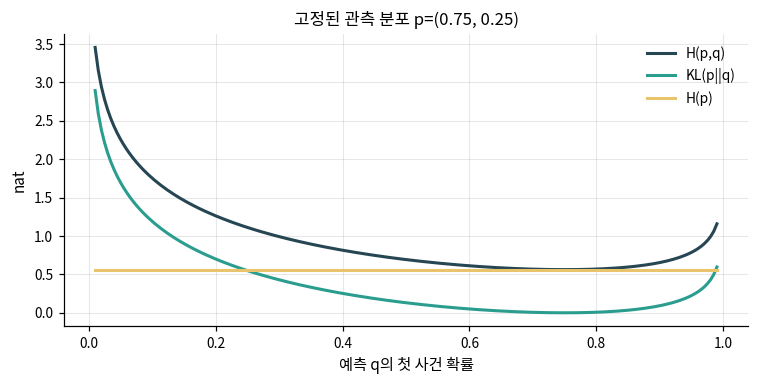

In [9]:
probabilities = np.linspace(.01, .99, 199)
ce_curve = np.array([cross_entropy(p, [value, 1-value]) for value in probabilities])
kl_curve = np.array([categorical_kl(p, [value, 1-value]) for value in probabilities])
plot_curves(probabilities, {'H(p,q)': ce_curve, 'KL(p||q)': kl_curve, 'H(p)': np.full_like(probabilities, entropy(p))},
            title='고정된 관측 분포 p=(0.75, 0.25)', xlabel='예측 q의 첫 사건 확률', ylabel='nat')

두 곡선의 차이는 항상 $H(p)$입니다. 고정된 관측 분포에서 CE를 줄이면 KL도 같은 만큼 줄어듭니다.
연속 분포에서는 합이 적분, 확률이 밀도로 바뀝니다. 밀도값은 1보다 클 수 있어 **미분 entropy** $-\mathbb E[\log p(X)]$는 음수도 가능합니다.
Gaussian에서는 $h=\tfrac12[D(1+\log(2\pi))+\log\det\Sigma]$입니다. 표준화된 제곱 거리의 기댓값이 $D$라는 사실을 로그 밀도에 대입해 얻습니다.

In [10]:
gaus_entropy = .5 * (2 * (1 + np.log(2*np.pi)) + np.linalg.slogdet(Sigma)[1])
monte_carlo_entropy = -gaussian_logpdf(samples, mu, Sigma).mean()
assert abs(gaus_entropy - monte_carlo_entropy) < .03
print('Gaussian entropy 해석식 / 샘플 평균:', gaus_entropy, monte_carlo_entropy)

Gaussian entropy 해석식 / 샘플 평균: 3.5310242469692907 3.5372813163988632


## 4. 관측에서 Gaussian 학습하기: MLE와 MAP

대각 공분산 $\operatorname{diag}(e^{\ell_1},\ldots,e^{\ell_D})$를 사용하면 관측 하나의 음의 로그 밀도는
$\tfrac12\sum_j[\log(2\pi)+\ell_j+(x_j-\mu_j)^2e^{-\ell_j}]$입니다.
**MLE(최대우도 추정)** 는 관측 평균 NLL을 최소화합니다.

$$\partial_{\mu_j}L=\frac1N\sum_n(\mu_j-X_{nj})e^{-\ell_j},\qquad
\partial_{\ell_j}L=\frac12\left[1-\frac1N\sum_n(X_{nj}-\mu_j)^2e^{-\ell_j}\right].$$

이를 0으로 놓으면 평균은 관측 평균, 분산은 분모 $N$의 관측 분산이 됩니다. 기울기 학습 결과를 이 해석해와 비교합니다.
손실은 **관측 축에서 평균, 좌표 축에서 합**입니다.

In [11]:
def diagonal_nll(X, mu, logvar):
    residual = mu - X
    inverse_variance = np.exp(-logvar)
    loss = .5 * np.mean(np.sum(np.log(2*np.pi) + logvar + residual**2 * inverse_variance, axis=1))
    dmu = residual.mean(axis=0) * inverse_variance
    dlogvar = .5 * (1 - (residual**2).mean(axis=0) * inverse_variance)
    return loss, dmu, dlogvar

In [12]:
X_fit = sample_gaussian(mu, Sigma, 600, rng)
X_holdout = sample_gaussian(mu, Sigma, 400, rng)
mu_fit = np.array([-.3, .4])
logvar_fit = np.array([.2, -.1])
loss, dmu, dlogvar = diagonal_nll(X_fit, mu_fit, logvar_fit)
grad_errors = [
    rel_error(dmu, numerical_gradient(lambda: diagonal_nll(X_fit, mu_fit, logvar_fit)[0], mu_fit)),
    rel_error(dlogvar, numerical_gradient(lambda: diagonal_nll(X_fit, mu_fit, logvar_fit)[0], logvar_fit)),
]
assert max(grad_errors) < 1e-7
history = []
for step in range(1200):
    loss, dmu, dlogvar = diagonal_nll(X_fit, mu_fit, logvar_fit)
    history.append(loss)
    mu_fit -= .08 * dmu
    logvar_fit -= .08 * dlogvar
final_nll = diagonal_nll(X_fit, mu_fit, logvar_fit)[0]
np.testing.assert_allclose(mu_fit, X_fit.mean(axis=0), atol=1e-7)
np.testing.assert_allclose(np.exp(logvar_fit), X_fit.var(axis=0), atol=1e-7)
print('NLL:', history[0], '→', final_nll, '기울기 상대 오차:', max(grad_errors))
print('학습 평균:', mu_fit, '학습 분산:', np.exp(logvar_fit))
print('검증 대각 NLL:', diagonal_nll(X_holdout, mu_fit, logvar_fit)[0])

NLL: 8.22924940783883 → 3.770006347507251 기울기 상대 오차: 1.7422830377106247e-10
학습 평균: [ 1.07844 -1.96366] 학습 분산: [3.68781 1.74932]
검증 대각 NLL: 3.8817441865570714


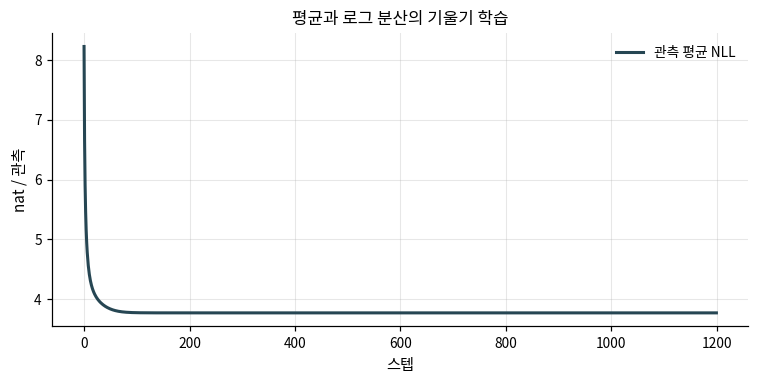

In [13]:
plot_curves(np.arange(len(history)), {'관측 평균 NLL': history}, title='평균과 로그 분산의 기울기 학습', ylabel='nat / 관측')

대각 모형은 각 좌표의 분포를 평균·분산으로 요약하며, 좌표 사이의 공분산은 0으로 둡니다. 공분산 전체를 쓰는 모형은 비대각 성분까지 추정합니다.
아래에서 같은 학습 관측으로 두 모형을 맞추고 별도의 관측에서 비교합니다.

In [14]:
fit_centered = X_fit - X_fit.mean(axis=0)
full_covariance = fit_centered.T @ fit_centered / len(X_fit)
full_holdout_nll = -gaussian_logpdf(X_holdout, X_fit.mean(axis=0), full_covariance).mean()
diagonal_holdout_nll = diagonal_nll(X_holdout, mu_fit, logvar_fit)[0]
print('검증 NLL 전체 공분산 / 대각 공분산:', full_holdout_nll, diagonal_holdout_nll)

검증 NLL 전체 공분산 / 대각 공분산: 3.573965686146029 3.8817441865570714


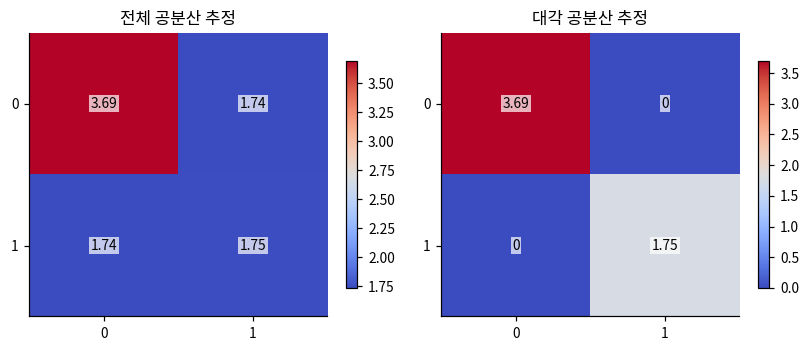

In [15]:
plot_matrices([full_covariance, np.diag(np.exp(logvar_fit))], ['전체 공분산 추정', '대각 공분산 추정'])

### 사전분포가 붙으면 MAP

스칼라 관측 $x_n\sim\mathcal N(\theta,\sigma^2)$와 사전분포 $\theta\sim\mathcal N(0,\tau^2)$를 정합니다.
Bayes 식 $p(\theta\mid x)\propto p(x\mid\theta)p(\theta)$에서 음의 로그를 취하면

$$J(\theta)=\frac1{2\sigma^2}\sum_n(x_n-\theta)^2+\frac{\theta^2}{2\tau^2}+\text{상수}.$$

이를 최소화하는 **MAP(최대사후 추정)** 는 $\theta_{MAP}=\sum_nx_n/(N+\sigma^2/\tau^2)$입니다.
MLE는 $\bar x$이고, MAP는 사전 평균 0 쪽으로 이동합니다. $J/N$으로 평균 규약을 바꾸면 사전 항의 계수도 $1/N$이 됩니다.
MAP는 사후분포의 최빈값 하나를 고르는 추정이며, 사후분포 전체를 얻는 계산으로도 이어집니다.

In [16]:
observed = np.array([1., 2., 3.])
sigma2, tau2 = 1., .5
theta_mle = observed.mean()
theta_map = observed.sum() / (len(observed) + sigma2 / tau2)
np.testing.assert_allclose(theta_map, 1.2)
stationary = np.sum(theta_map - observed) / sigma2 + theta_map / tau2
np.testing.assert_allclose(stationary, 0, atol=1e-14)
print('MLE / MAP:', theta_mle, theta_map)

MLE / MAP: 2.0 1.2


## 5. 대각 Gaussian KL: VAE를 읽을 준비

관측마다 $q_n(z)=\mathcal N(\mu_{q,n},\operatorname{diag}(e^{\ell_{q,n}}))$를 만들고,
$p(z)=\mathcal N(\mu_p,\operatorname{diag}(e^{\ell_p}))$와 비교합니다.
$D_{KL}(q\|p)=\mathbb E_q[\log q(z)-\log p(z)]$에 로그 밀도를 넣습니다.
$\mathbb E_q[(z_j-\mu_{p,j})^2]=e^{\ell_{q,j}}+(\mu_{q,j}-\mu_{p,j})^2$를 쓰면

$$K=\frac1{2N}\sum_{n,j}\left[\ell_{p,j}-\ell_{q,nj}
+\frac{e^{\ell_{q,nj}}+(\mu_{q,nj}-\mu_{p,j})^2}{e^{\ell_{p,j}}}-1\right].$$

고정된 $p$에 대한 미분은
$\partial_{\mu_q}K=(\mu_q-\mu_p)e^{-\ell_p}/N$,
$\partial_{\ell_q}K=(e^{\ell_q-\ell_p}-1)/(2N)$입니다.
$p$가 표준정규이면 $K=\tfrac1{2N}\sum(\mu_q^2+e^{\ell_q}-1-\ell_q)$로 단순해집니다.

In [17]:
def diagonal_kl(q_mu, q_logvar, p_mu, p_logvar):
    """q:(N,D), p:(D,), 반환: 관측 평균 KL와 q 파라미터의 기울기."""
    difference = q_mu - p_mu
    ratio = np.exp(q_logvar - p_logvar)
    inverse_pvar = np.exp(-p_logvar)
    loss = .5 * np.mean(np.sum(p_logvar - q_logvar + ratio + difference**2 * inverse_pvar - 1, axis=1))
    dmu = difference * inverse_pvar / len(q_mu)
    dlogvar = .5 * (ratio - 1) / len(q_mu)
    return loss, dmu, dlogvar

In [18]:
q_mu = np.array([[1., -.5], [.2, .8]])
q_logvar = np.log(np.array([[2., .5], [1.3, .7]]))
p_mu = np.array([-.3, .2])
p_logvar = np.log(np.array([.8, 1.7]))
kl, dmu, dlogvar = diagonal_kl(q_mu, q_logvar, p_mu, p_logvar)
kl_grad_errors = [
    rel_error(dmu, numerical_gradient(lambda: diagonal_kl(q_mu, q_logvar, p_mu, p_logvar)[0], q_mu)),
    rel_error(dlogvar, numerical_gradient(lambda: diagonal_kl(q_mu, q_logvar, p_mu, p_logvar)[0], q_logvar)),
]
assert kl >= 0 and max(kl_grad_errors) < 1e-7
np.testing.assert_allclose(diagonal_kl(p_mu[None], p_logvar[None], p_mu, p_logvar)[0], 0, atol=1e-14)
# 기대값의 분포가 q라는 점을 샘플 계산으로 대조합니다.
mc_estimates = []
for qm, ql in zip(q_mu, q_logvar):
    z_samples = rng.normal(size=(100000, 2)) * np.exp(.5 * ql) + qm
    log_q = gaussian_logpdf(z_samples, qm, np.diag(np.exp(ql)))
    log_p = gaussian_logpdf(z_samples, p_mu, np.diag(np.exp(p_logvar)))
    mc_estimates.append(np.mean(log_q - log_p))
assert abs(np.mean(mc_estimates) - kl) < .02
print('KL 해석식 / Monte Carlo:', kl, np.mean(mc_estimates), '미분 오차:', max(kl_grad_errors))

KL 해석식 / Monte Carlo: 1.116290607977085 1.1174150033954557 미분 오차: 1.638037853276656e-10


## 6. 샘플링과 미분을 연결하기

$z=\mu+e^{\ell/2}\epsilon$, $\epsilon\sim\mathcal N(0,I)$로 쓰면 잡음의 분포를 고정한 채 평균·분산에 따른 샘플 변화를 계산할 수 있습니다.
이것이 **재매개화(reparameterization)** 입니다. 이번 절은 $\mu,\ell,z$가 모두 $(N,D)$인 경우입니다. $G=\partial L/\partial z$가 오면
$d\mu=G$, $d\ell=G\odot\epsilon\odot e^{\ell/2}/2$입니다. $\odot$는 원소별 곱입니다.
공유 파라미터 $(D,)$가 샘플 $(N,D)$로 broadcasting되면 각 기울기를 샘플 축에서 합해 $(D,)$로 돌려줍니다. 아래 검산은 같은 잡음에서 미분을 대조합니다. 여러 새 잡음의 평균은 기대 손실의 기울기를 추정하는 다음 단계로 연결됩니다.

In [19]:
fixed_noise = rng.normal(size=q_mu.shape)
sampled_z = q_mu + np.exp(.5 * q_logvar) * fixed_noise
upstream = rng.normal(size=q_mu.shape)
reparameterized_dlogvar = .5 * upstream * np.exp(.5 * q_logvar) * fixed_noise
reparam_error = rel_error(reparameterized_dlogvar, numerical_gradient(
    lambda: np.sum((q_mu + np.exp(.5*q_logvar)*fixed_noise) * upstream), q_logvar))
assert reparam_error < 1e-7
print('고정 잡음에서 재매개화 미분 오차:', reparam_error)

고정 잡음에서 재매개화 미분 오차: 1.3070466284896373e-10


## 7. 직접 바꾸기: 표준정규에서 다른 기준 분포로

`my_diagonal_kl(q_mu, q_logvar, p_mu, p_logvar)`를 작성하고 `(loss, dmu, dlogvar)`를 반환해 보세요.
$p$의 분산이 1인 경우부터 손계산한 뒤, 서로 다른 평균·분산과 배치 크기로 확장합니다.
검사기 다음에는 $q$의 평균을 한 축으로 움직여 KL 곡선을 그려 보세요. 분산이 작은 $p$는 같은 거리의 평균 이동에 어떤 비용을 줄까요?

In [20]:
def check_diagonal_kl(candidate):
    local_rng = np.random.default_rng(127)
    for N, D in [(1, 3), (4, 2)]:
        qm = local_rng.normal(size=(N, D))
        ql = local_rng.normal(size=(N, D)) * .4
        pm = local_rng.normal(size=D)
        pl = local_rng.normal(size=D) * .6
        value, dm, dl = candidate(qm.copy(), ql.copy(), pm.copy(), pl.copy())
        assert np.ndim(value) == 0 and np.shape(dm) == qm.shape and np.shape(dl) == ql.shape
        reference = diagonal_kl(qm, ql, pm, pl)[0]
        np.testing.assert_allclose(value, reference, rtol=1e-10, atol=1e-12)
        for analytic, parameter in [(dm, qm), (dl, ql)]:
            numeric = numerical_gradient(lambda: diagonal_kl(qm, ql, pm, pl)[0], parameter)
            assert rel_error(analytic, numeric) < 1e-7
        repeated_value, repeated_dm, repeated_dl = candidate(np.repeat(qm, 2, axis=0), np.repeat(ql, 2, axis=0), pm, pl)
        np.testing.assert_allclose(repeated_value, value)
        np.testing.assert_allclose(repeated_dm, np.repeat(dm, 2, axis=0) / 2)
        np.testing.assert_allclose(repeated_dl, np.repeat(dl, 2, axis=0) / 2)
    return '통과: KL 방향·로그 분산·두 미분·관측 평균'

In [21]:
print(check_diagonal_kl(diagonal_kl))
means = np.linspace(-2, 2, 101)
kl_by_variance = {}
for p_variance in [.5, 1., 2.]:
    kl_by_variance[f'p 분산 {p_variance}'] = [
        diagonal_kl(np.array([[m]]), np.array([[0.]]), np.array([0.]), np.log([p_variance]))[0]
        for m in means]

통과: KL 방향·로그 분산·두 미분·관측 평균


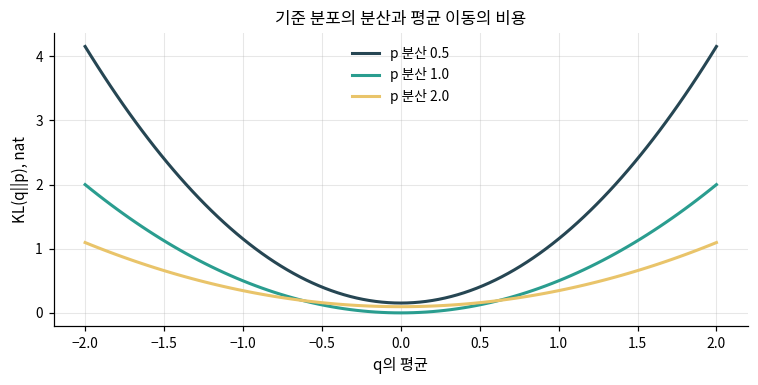

In [22]:
plot_curves(means, kl_by_variance, title='기준 분포의 분산과 평균 이동의 비용', xlabel='q의 평균', ylabel='KL(q||p), nat')

**준비도 확인**

- 행에 저장한 표준정규 샘플에 `L.T`를 곱하는 이유를 공분산으로 확인할 수 있나요?
- 분산의 로그 $\ell$에서 표준편차가 왜 $e^{\ell/2}$인지 설명할 수 있나요?
- $H(p,q)=H(p)+KL(p\|q)$와 분류 CE의 관계를 손계산할 수 있나요?
- 평균 NLL을 사용할 때 사전 항의 계수가 어떻게 달라지는지 유도할 수 있나요?
- Gaussian KL의 기대값을 어느 분포로 계산하는지, 어떤 축을 평균하는지 말할 수 있나요?

다음 [13 자동미분](13_autodiff.ipynb)에서 이런 국소 미분을 그래프에 연결하고 PyTorch와 대조합니다.
VAE 단원에서는 여기의 Gaussian KL·재매개화에 잠재변수 모형과 ELBO 유도를 연결합니다.

참고: [Stanford CS229 다변량 Gaussian](https://cs229.stanford.edu/section/gaussians.pdf)의 밀도·공분산,
[Kingma·Welling의 VAE 원논문](https://arxiv.org/abs/1312.6114)의 대각 Gaussian KL과 재매개화.